# Data Exploration

In [2]:
import os
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from mutagen.mp3 import MP3


Total valid files:  4193
     Dataset   Class  Count  Avg_Duration_Sec  Total_Duration_Sec  Min_Duration  Max_Duration                        Sample_Rates
kaggle_extra  amepip     21             11.37              238.77          0.68         39.79                      {48000, 44100}
kaggle_extra  amerob    405             74.66            30236.36          2.34        926.71 {48000, 16000, 22050, 24000, 44100}
kaggle_extra  brebla      1             29.47               29.47         29.47         29.47                             {48000}
kaggle_extra  casfin     47            115.38             5422.87         10.16        627.65                      {48000, 44100}
kaggle_extra  clanut     12             40.26              483.09          6.01        167.61                      {48000, 44100}
kaggle_extra  daejun    252             58.18            14661.87          2.11        635.62        {48000, 22050, 44100, 24000}
kaggle_extra  dusfly     16            100.43             1606.8

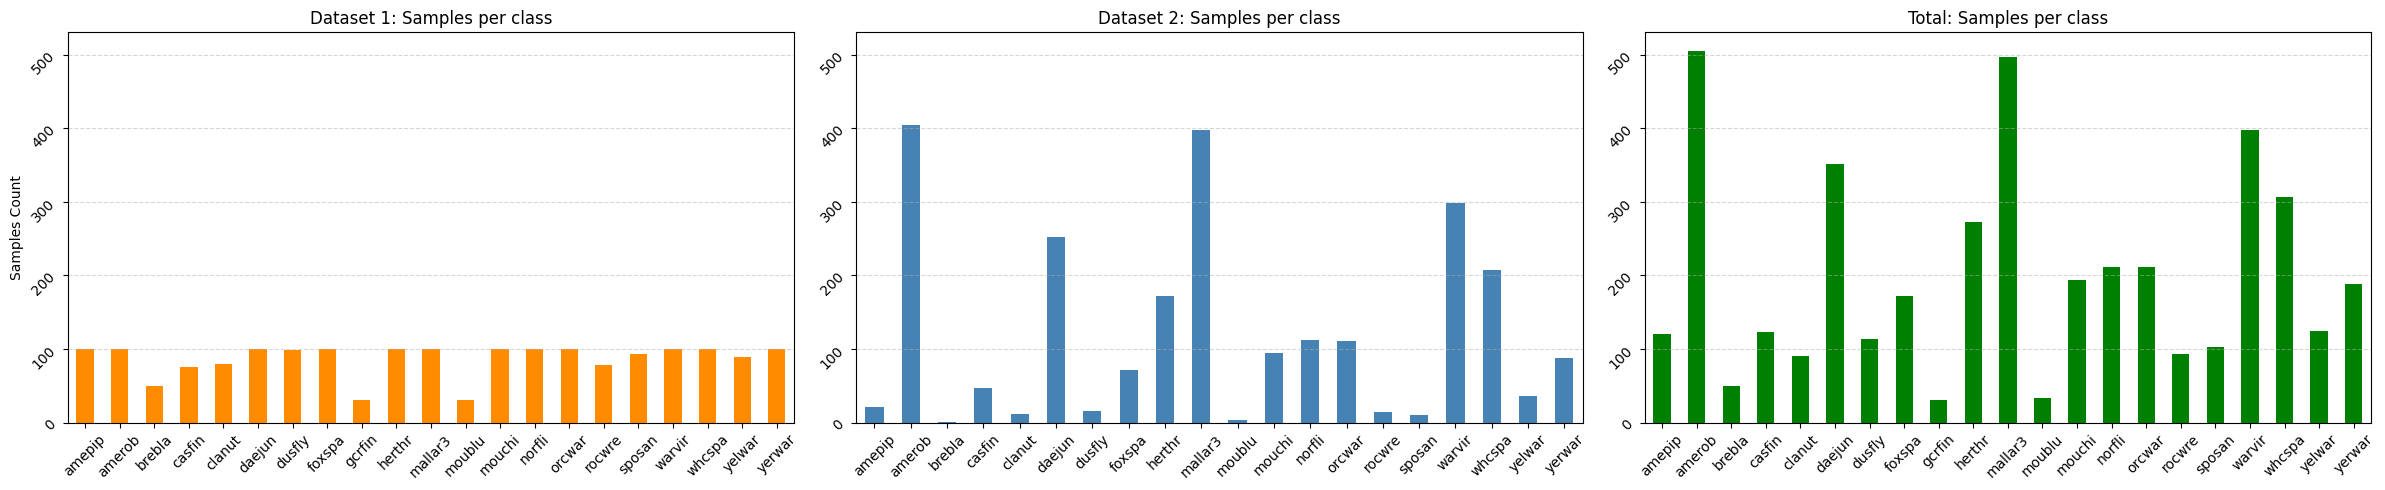

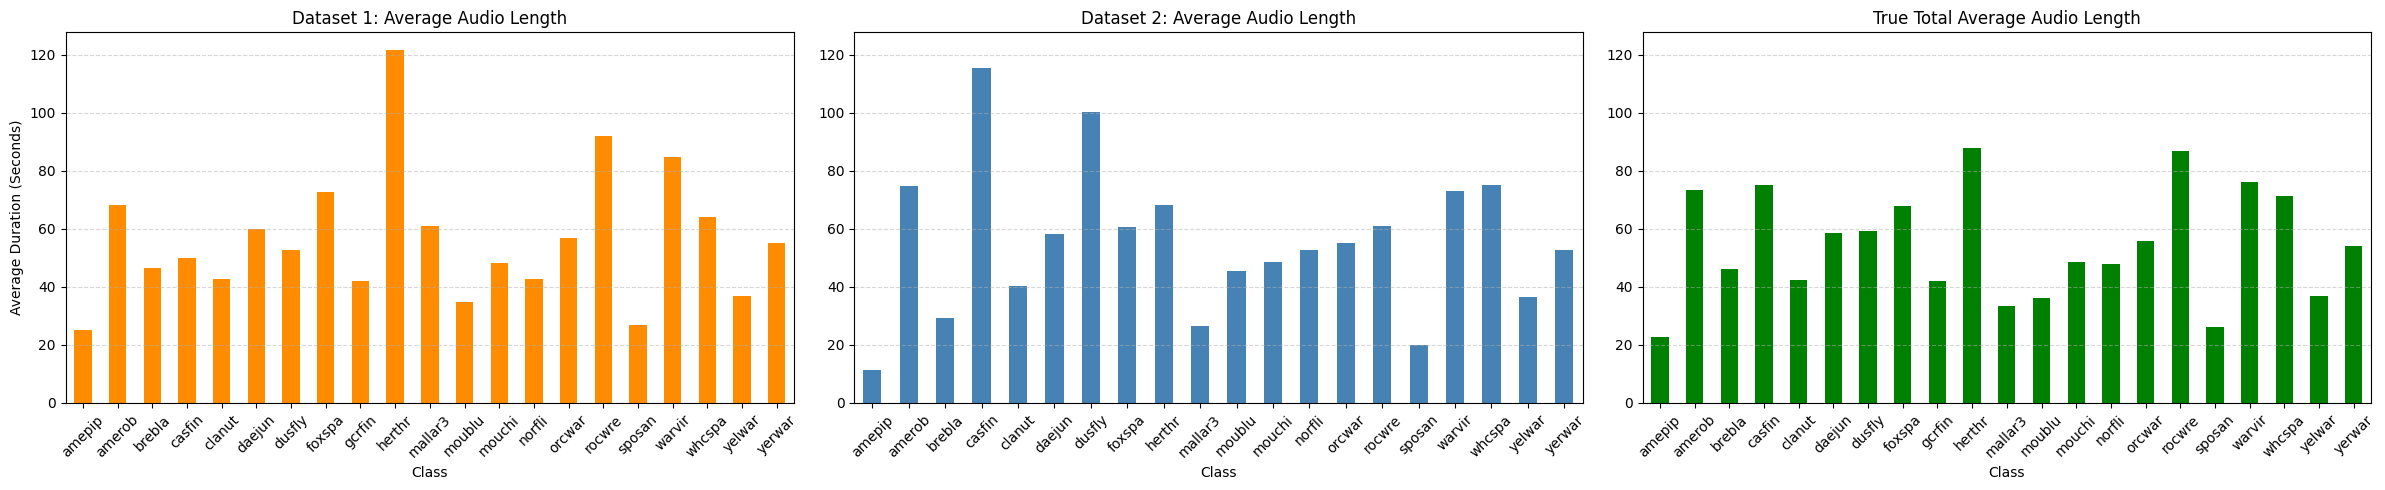

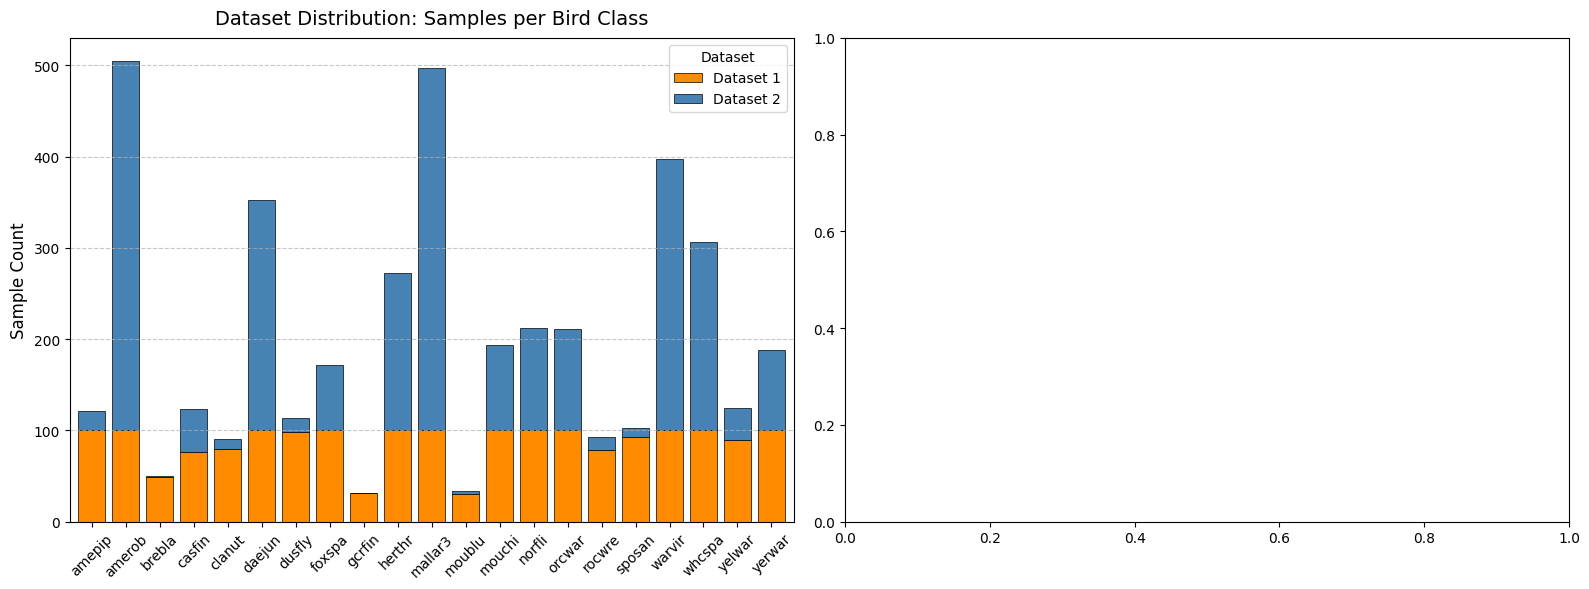

In [8]:
data_dict = defaultdict(dict)
stats_dict = defaultdict(lambda: defaultdict(list))

total = 0
malformed_files = 0

for root, dirs, files in os.walk("./data"):
    head, class_name = os.path.split(root)
    data_set = os.path.basename(head)

    mp3_files = [f for f in files if f.lower().endswith(".mp3")]
    file_len = len(mp3_files)

    if file_len != 0:
        total += file_len
        paths = []

        for file in mp3_files:
            file_path = os.path.join(root, file)
            paths.append(file_path)

            try:
                audio = MP3(file_path)
                stats_dict[data_set][class_name].append({
                    "duration": audio.info.length,
                    "sample_rate": audio.info.sample_rate
                })
            except Exception:
                malformed_files += 1

        data_dict[data_set][class_name] = paths

print("\nTotal valid files: ", total)
if malformed_files > 0:
    print("Malformed/Unreadable files: ", malformed_files)


if "kaggle_extra" in data_dict and "xenoCanto" in data_dict:
    data_kaggle = pd.DataFrame.from_dict(data_dict["kaggle_extra"], "index").T
    data_xeno = pd.DataFrame.from_dict(data_dict["xenoCanto"], "index").T

    counts_kaggle = data_kaggle.count()
    counts_xeno = data_xeno.count()

    total_counts = counts_kaggle.add(counts_xeno, fill_value=0)

    fig1, axes1 = plt.subplots(1, 3, figsize=(24, 5), sharey=True)

    counts_xeno.plot(kind="bar", ax=axes1[0], color='darkorange')
    axes1[0].set_title("Dataset 1: Samples per class")
    axes1[0].set_ylabel("Samples Count")
    axes1[0].tick_params(rotation=45)

    counts_kaggle.plot(kind="bar", ax=axes1[1], color='steelblue')
    axes1[1].set_title("Dataset 2: Samples per class")
    axes1[1].set_ylabel("Samples Count")
    axes1[1].tick_params(rotation=45)

    total_counts.plot(kind="bar", ax=axes1[2], color='green')
    axes1[2].set_title("Total: Samples per class")
    axes1[2].set_ylabel("Samples Count")
    axes1[2].tick_params(rotation=45)

    for ax in axes1:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.tick_params(labelleft=True)

    plt.tight_layout()


insights_records = []

for data_set, classes in stats_dict.items():
    for class_name, stats in classes.items():
        if not stats: continue

        durations = [s["duration"] for s in stats]
        sample_rates = [s["sample_rate"] for s in stats]

        insights_records.append({
            "Dataset": data_set,
            "Class": class_name,
            "Count": len(durations),
            "Avg_Duration_Sec": sum(durations) / len(durations),
            "Total_Duration_Sec": sum(durations),
            "Min_Duration": min(durations),
            "Max_Duration": max(durations),
            "Sample_Rates": set(sample_rates)
        })

df_insights = pd.DataFrame(insights_records)


df_kaggle_insights = df_insights[df_insights["Dataset"] == "kaggle_extra"].set_index("Class")
df_xeno_insights = df_insights[df_insights["Dataset"] == "xenoCanto"].set_index("Class")

df_combined = df_insights.groupby("Class")[["Count", "Total_Duration_Sec"]].sum()
total_avg_duration = df_combined["Total_Duration_Sec"] / df_combined["Count"]

fig2, axes2 = plt.subplots(1, 3, figsize=(24, 5), sharey=True)

df_xeno_insights["Avg_Duration_Sec"].plot(kind="bar", ax=axes2[0], color='darkorange')
axes2[0].set_title("Dataset 1: Average Audio Length")
axes2[0].set_ylabel("Average Duration (Seconds)")
axes2[0].tick_params(axis='x', rotation=45)

df_kaggle_insights["Avg_Duration_Sec"].plot(kind="bar", ax=axes2[1], color='steelblue')
axes2[1].set_title("Dataset 2: Average Audio Length")
axes2[1].set_ylabel("Average Duration (Seconds)")
axes2[1].tick_params(axis='x', rotation=45)

total_avg_duration.plot(kind="bar", ax=axes2[2], color='green')
axes2[2].set_title("True Total Average Audio Length")
axes2[2].set_ylabel("Average Duration (Seconds)")
axes2[2].tick_params(axis='x', rotation=45)

for ax in axes2:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.tick_params(labelleft=True)

plt.tight_layout()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

table_counts = df_insights.pivot(index="Class", columns="Dataset", values="Count").fillna(0).astype(int)
table_avg_dur = df_insights.pivot(index="Class", columns="Dataset", values="Avg_Duration_Sec").round(2).fillna(0)



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

table_counts = table_counts[['xenoCanto', 'kaggle_extra']]
table_avg_dur = table_avg_dur[['xenoCanto', 'kaggle_extra']]
clean_names = {'xenoCanto': 'Dataset 1', 'kaggle_extra': 'Dataset 2'}
table_counts = table_counts.rename(columns=clean_names)
colors = ['darkorange', 'steelblue']

table_counts.plot(kind="bar", stacked=True, ax=axes[0], color=colors, width=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_title("Dataset Distribution: Samples per Bird Class", fontsize=14, pad=10)
axes[0].set_ylabel("Sample Count", fontsize=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title="Dataset", loc='upper right')


plt.tight_layout()

table_counts.columns.name = None
table_avg_dur.columns.name = None


df_detailed = df_insights.copy()
df_detailed["Avg_Duration_Sec"] = df_detailed["Avg_Duration_Sec"].round(2)
df_detailed["Min_Duration"] = df_detailed["Min_Duration"].round(2)
df_detailed["Max_Duration"] = df_detailed["Max_Duration"].round(2)
df_detailed["Total_Duration_Sec"] = df_detailed["Total_Duration_Sec"].round(2)
print(df_detailed.to_string(index=False))

grand_total_duration = 0
grand_total_samples = 0

for dataset_name in stats_dict.keys():
    dataset_duration = 0
    dataset_samples = 0

    for class_name, stats in stats_dict[dataset_name].items():
        durations = [s["duration"] for s in stats]
        dataset_duration += sum(durations)
        dataset_samples += len(durations)

    dataset_avg_duration = (dataset_duration / dataset_samples) if dataset_samples > 0 else 0

    print(f"\nDataset: {dataset_name.upper()}")
    print(f"  - Total Samples:      {dataset_samples}")
    print(f"  - Total Audio Length: {dataset_duration:.2f} seconds ({dataset_duration/3600:.2f} hours)")
    print(f"  - Average Length:     {dataset_avg_duration:.2f} seconds per sample")

    grand_total_duration += dataset_duration
    grand_total_samples += dataset_samples

grand_avg_duration = (grand_total_duration / grand_total_samples) if grand_total_samples > 0 else 0

print(f"  - Total Samples:      {grand_total_samples}")
print(f"  - Total Audio Length: {grand_total_duration:.2f} seconds ({grand_total_duration/3600:.2f} hours)")
print(f"  - Overall Average:    {grand_avg_duration:.2f} seconds per sample")

plt.show()

# Result exploration

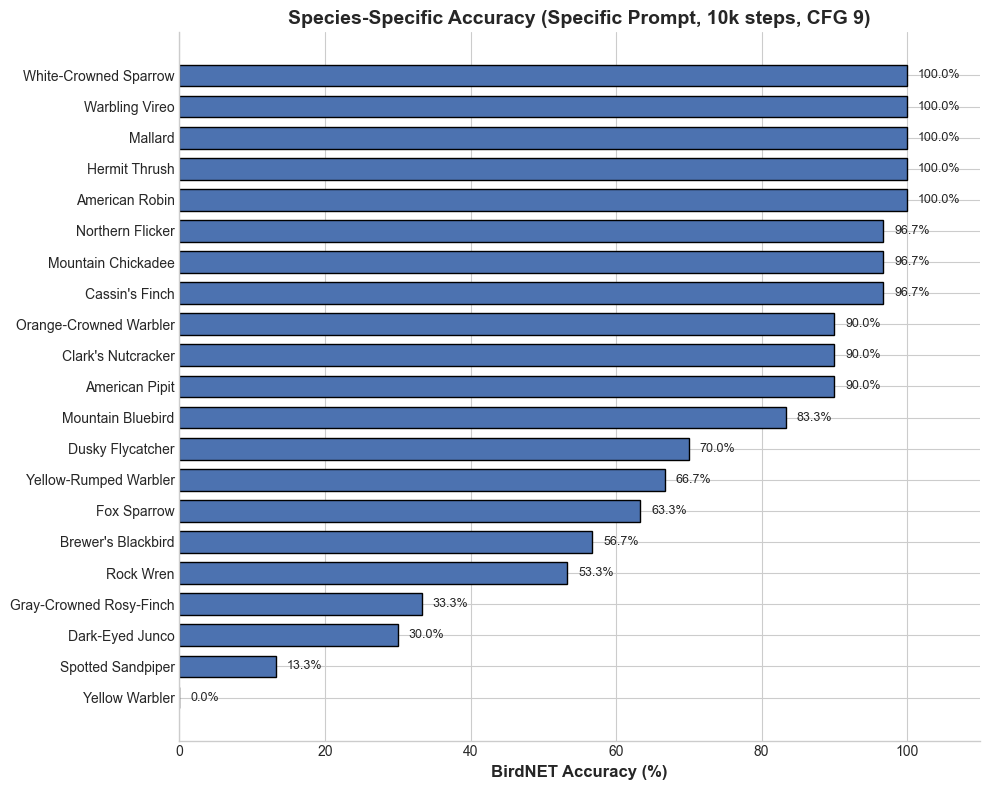

In [2]:
import matplotlib.pyplot as plt
import numpy as np


data = {
    "American Robin": 100.0, "Hermit Thrush": 100.0, "Mallard": 100.0, 
    "Warbling Vireo": 100.0, "White-Crowned Sparrow": 100.0, 
    "Cassin's Finch": 96.7, "Mountain Chickadee": 96.7, "Northern Flicker": 96.7, 
    "American Pipit": 90.0, "Clark's Nutcracker": 90.0, "Orange-Crowned Warbler": 90.0,
    "Mountain Bluebird": 83.3, "Dusky Flycatcher": 70.0, "Yellow-Rumped Warbler": 66.7, 
    "Fox Sparrow": 63.3, "Brewer's Blackbird": 56.7, "Rock Wren": 53.3, 
    "Gray-Crowned Rosy-Finch": 33.3, "Dark-Eyed Junco": 30.0, 
    "Spotted Sandpiper": 13.3, "Yellow Warbler": 0.0
}


sorted_data = dict(sorted(data.items(), key=lambda item: item[1]))
species = list(sorted_data.keys())
accuracy = list(sorted_data.values())
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(species, accuracy, color='#4C72B0', edgecolor='black', height=0.7)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', ha='left', fontsize=9)

ax.set_xlabel('BirdNET Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Species-Specific Accuracy (Specific Prompt, 10k steps, CFG 9)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.tight_layout()
plt.savefig('birdnet_accuracy_chart.png')
plt.show()